In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_parquet("../data/processed/market_macro_dataset.parquet")
data = data.sort_index()

In [2]:
data.columns

Index(['SP500_close', 'SP500_volume', 'NASDAQ_close', 'NASDAQ_volume',
       'NIFTY50_close', 'NIFTY50_volume', 'VIX_close', 'VIX_volume',
       'DXY_close', 'DXY_volume', 'US10Y_close', 'US10Y_volume', 'GOLD_close',
       'GOLD_volume', 'OIL_close', 'OIL_volume', 'BTC_close', 'BTC_volume',
       'US10Y', 'US2Y', 'FEDFUNDS', 'CPI', 'UNEMPLOYMENT', 'INDPRO',
       'YIELD_SPREAD'],
      dtype='str')

In [3]:
data = data.drop(
    columns=[
        "NIFTY50_close",
        "NIFTY50_volume",
        "BTC_close",
        "BTC_volume"
    ],
    errors="ignore"
)

In [4]:
macro_cols = [
    "CPI",
    "UNEMPLOYMENT",
    "INDPRO",
    "FEDFUNDS"
]

for col in macro_cols:
    data[col] = data[col].shift(1)

In [5]:
price_cols = [
    "SP500_close",
    "NASDAQ_close",
    "VIX_close",
    "DXY_close",
    "GOLD_close",
    "OIL_close",
    "US10Y_close"
]

prices = data[price_cols].copy()

In [6]:
prices = prices.replace(0, np.nan)
prices = prices.ffill()


In [7]:
with np.errstate(divide="ignore", invalid="ignore"):
    returns = np.log(prices / prices.shift(1))

returns = returns.replace([np.inf, -np.inf], np.nan)
returns = returns.dropna()

In [8]:
features = pd.DataFrame(index=returns.index)

In [9]:
features["spx_vol_20"] = returns["SP500_close"].rolling(20).std()
features["spx_vol_60"] = returns["SP500_close"].rolling(60).std()
features["spx_vol_120"] = returns["SP500_close"].rolling(120).std()

features["nasdaq_vol_20"] = returns["NASDAQ_close"].rolling(20).std()

In [10]:
features["vol_ratio"] = (
    features["spx_vol_20"] /
    features["spx_vol_60"]
)

In [11]:
features["vol_gradient"] = (
    features["spx_vol_20"] -
    features["spx_vol_20"].shift(10)
)

In [12]:
features["spx_mom_20"] = prices["SP500_close"].pct_change(20)
features["spx_mom_60"] = prices["SP500_close"].pct_change(60)

features["nasdaq_mom_20"] = prices["NASDAQ_close"].pct_change(20)
features["gold_mom_20"] = prices["GOLD_close"].pct_change(20)

In [13]:
features["vix_level"] = data.loc[features.index, "VIX_close"]
features["vix_return"] = returns["VIX_close"]
features["vix_vol"] = returns["VIX_close"].rolling(20).std()

In [14]:
features["spx_gold_corr"] = (
    returns["SP500_close"]
    .rolling(60)
    .corr(returns["GOLD_close"])
)

features["spx_vix_corr"] = (
    returns["SP500_close"]
    .rolling(60)
    .corr(returns["VIX_close"])
)

In [15]:
features["gold_return"] = returns["GOLD_close"]
features["oil_return"] = returns["OIL_close"]

In [16]:
features["dxy_return"] = returns["DXY_close"]

In [17]:
features["yield_spread"] = data.loc[features.index, "YIELD_SPREAD"]

features["yield_spread_change"] = (
    data.loc[features.index, "YIELD_SPREAD"].diff()
)

In [18]:
features["us10y_change"] = (
    data.loc[features.index, "US10Y"].diff()
)

In [19]:
features["fed_rate"] = data.loc[features.index, "FEDFUNDS"]

features["inflation"] = (
    data.loc[features.index, "CPI"].pct_change(12)
)

features["unemployment"] = (
    data.loc[features.index, "UNEMPLOYMENT"]
)

features["industrial_prod"] = (
    data.loc[features.index, "INDPRO"].pct_change(12)
)

In [20]:
features["stress_indicator"] = (
    features["spx_vol_20"] * features["vix_level"]
)

In [21]:
features["volume_spike"] = (
    data.loc[features.index, "SP500_volume"] /
    data.loc[features.index, "SP500_volume"].rolling(60).mean()
)

features["amihud_illiquidity"] = (
    returns["SP500_close"].abs() /
    data.loc[features.index, "SP500_volume"]
)

In [22]:
rolling_mean = prices["SP500_close"].rolling(20).mean()
rolling_std = prices["SP500_close"].rolling(20).std()

features["spx_zscore"] = (
    prices["SP500_close"] - rolling_mean
) / rolling_std

## S&P 500 Return Feature

For regime diagnostics and downstream predictive modeling we require the raw S&P 500 return series.

Earlier we only retained the squared return (`spx_sq_return`) which is used as a proxy for volatility shocks.

We now also include the raw return:

$
r_t = \log(P_t) - \log(P_{t-1})
$

This allows us to analyze:

- mean returns per regime
- regime profitability
- predictive models conditioned on regimes

In [23]:
features["spx_return"] = returns["SP500_close"]

In [24]:
# ensure spx_return exists and is aligned with features index
features["spx_return"] = returns.loc[features.index, "SP500_close"]

### Squared Return Feature

Squared returns are included as a proxy for volatility spikes.

This feature helps the Hidden Markov Model detect transitions into high-volatility regimes.

In [25]:
features["spx_sq_return"] = (
    returns["SP500_close"] ** 2
)

In [26]:
features["us10y_vol"] = (
    returns["US10Y_close"].rolling(20).std()
)

### Market Stress Composite Index

Construct a stress index from three standardized components:
- equity volatility (`spx_vol_20`)
- VIX level (`vix_level`)
- volume spike (`volume_spike`)

Each component is standardized independently (separate `StandardScaler`) then summed.

In [27]:
from sklearn.preprocessing import StandardScaler

vol_scaler = StandardScaler()
vix_scaler = StandardScaler()
volume_scaler = StandardScaler()

vol_norm = vol_scaler.fit_transform(features[["spx_vol_20"]]).ravel()
vix_norm = vix_scaler.fit_transform(features[["vix_level"]]).ravel()
volume_norm = volume_scaler.fit_transform(features[["volume_spike"]]).ravel()

features["stress_index"] = vol_norm + vix_norm + volume_norm

In [28]:
features = features.replace([np.inf, -np.inf], np.nan)
features = features.dropna()

In [29]:
features = features.clip(
    lower=features.quantile(0.01),
    upper=features.quantile(0.99),
    axis=1
)

### Clean dataset before scaling

Drop rows with missing features (necessary before fitting the global scaler) and verify required columns (especially `spx_return`) are preserved.

In [30]:
# drop any remaining NaNs from the features dataframe before scaling
features = features.dropna()

# verify spx_return is present
missing = [c for c in ["spx_return", "spx_sq_return"] if c not in features.columns]
if missing:
    raise ValueError(f"Missing expected feature columns: {missing}")

print("features shape after dropna:", features.shape)

features shape after dropna: (7236, 33)


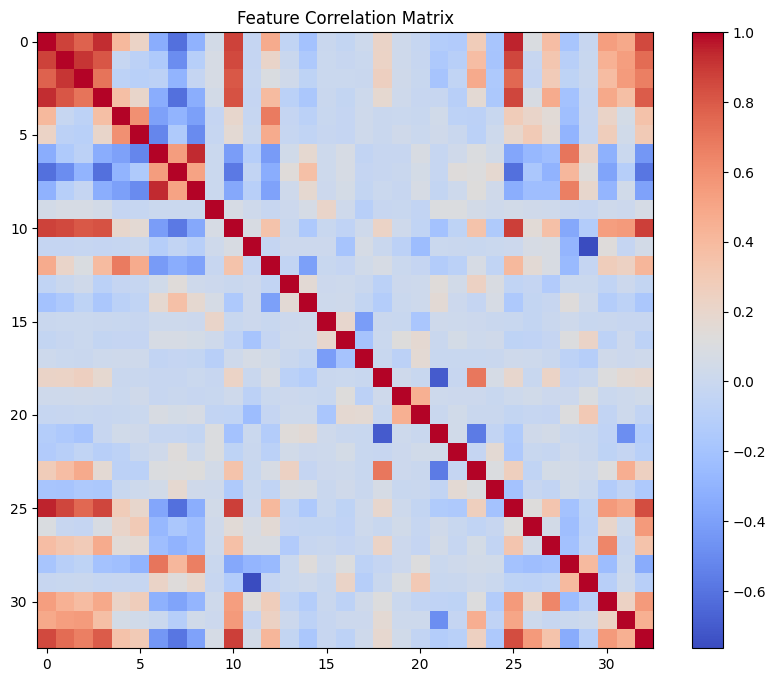

In [31]:
corr = features.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.show()

In [32]:
features.columns

Index(['spx_vol_20', 'spx_vol_60', 'spx_vol_120', 'nasdaq_vol_20', 'vol_ratio',
       'vol_gradient', 'spx_mom_20', 'spx_mom_60', 'nasdaq_mom_20',
       'gold_mom_20', 'vix_level', 'vix_return', 'vix_vol', 'spx_gold_corr',
       'spx_vix_corr', 'gold_return', 'oil_return', 'dxy_return',
       'yield_spread', 'yield_spread_change', 'us10y_change', 'fed_rate',
       'inflation', 'unemployment', 'industrial_prod', 'stress_indicator',
       'volume_spike', 'amihud_illiquidity', 'spx_zscore', 'spx_return',
       'spx_sq_return', 'us10y_vol', 'stress_index'],
      dtype='str')

In [33]:
drop_cols = [
    "spx_vol_120",
    "nasdaq_vol_20",
    "vix_vol",
    "nasdaq_mom_20",
    "stress_indicator",
    "yield_spread_change",
    "us10y_change"
]

features = features.drop(columns=drop_cols, errors="ignore")

In [34]:
features["yield_spread_diff"] = features["yield_spread"].diff()
features["fed_rate_diff"] = features["fed_rate"].diff()
features["unemployment_diff"] = features["unemployment"].diff()
features["industrial_prod_diff"] = features["industrial_prod"].diff()

In [35]:
features = features.drop(columns=[
    "yield_spread",
    "fed_rate",
    "unemployment",
    "industrial_prod"
])

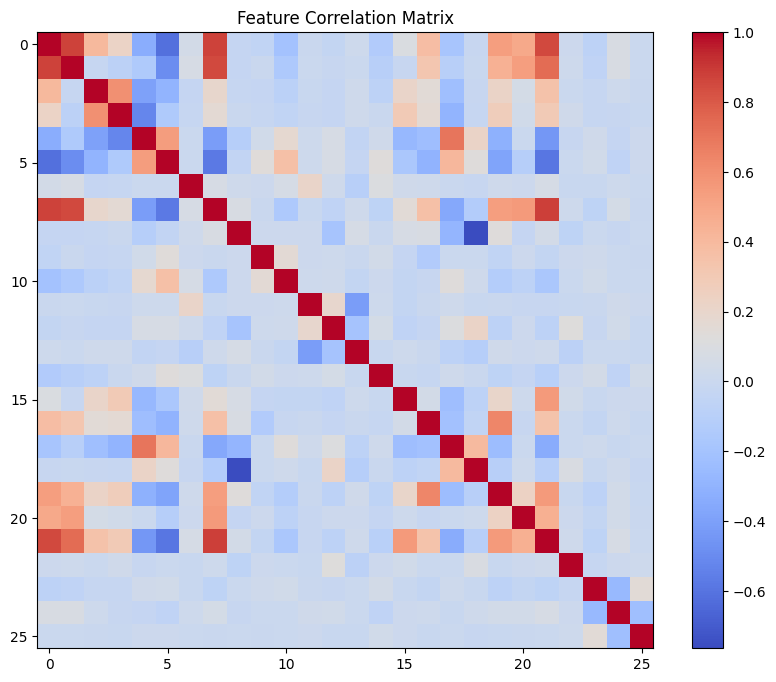

In [36]:
corr = features.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.show()

In [37]:
corr_matrix = features.corr()

corr_pairs = (
    corr_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.drop_duplicates()

corr_pairs.head(20)
high_corr = corr_pairs[corr_pairs > 0.9]

for (f1, f2), val in high_corr.items():
    print(f"{f1}  <->  {f2} : {val:.3f}")

In [38]:
features = features.drop(columns=["cost_pressure"], errors="ignore")

In [39]:
corr_matrix = features.corr()

corr_pairs = (
    corr_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.drop_duplicates()

high_corr = corr_pairs[corr_pairs > 0.9]

for (f1, f2), val in high_corr.items():
    print(f"{f1} <-> {f2} : {val:.3f}")

In [40]:
from sklearn.preprocessing import StandardScaler

# list columns to exclude from scaling (non-HMM columns)
exclude_from_scaling = ["spx_return"]

# columns to be scaled
to_scale_cols = [c for c in features.columns if c not in exclude_from_scaling]

scaler = StandardScaler()
scaled_vals = scaler.fit_transform(features[to_scale_cols])

features_scaled = pd.DataFrame(
    scaled_vals,
    columns=to_scale_cols,
    index=features.index
)

In [41]:
from statsmodels.tsa.stattools import adfuller

adf_results = {}

for col in features.columns:
    
    result = adfuller(features[col].dropna())
    
    adf_results[col] = {
        "ADF Statistic": result[0],
        "p-value": result[1]
    }

import pandas as pd

adf_table = pd.DataFrame(adf_results).T

adf_table

,ADF Statistic,p-value
spx_vol_20,-6.609380,6.434365e-09
spx_vol_60,-6.315307,3.161218e-08
vol_ratio,-16.335488,3.031625e-29
vol_gradient,-16.573623,1.860770e-29
spx_mom_20,-13.783586,9.199708e-26
spx_mom_60,-9.589228,2.057399e-16
gold_mom_20,-13.706045,1.263259e-25
vix_level,-5.624027,1.128080e-06
vix_return,-26.567861,0.000000e+00
spx_gold_corr,-7.290860,1.418478e-10


In [42]:
dist_stats = pd.DataFrame({
    "mean": features_scaled.mean(),
    "std": features_scaled.std(),
    "skew": features_scaled.skew(),
    "kurtosis": features_scaled.kurtosis()
})

dist_stats

,mean,std,skew,kurtosis
spx_vol_20,-1.099790e-16,1.000069,2.404837,8.187844
spx_vol_60,-7.855641e-17,1.000069,2.582575,8.787183
vol_ratio,-1.080151e-16,1.000069,0.184680,-0.255991
vol_gradient,9.819551e-19,1.000069,0.400606,2.632679
spx_mom_20,3.142256e-17,1.000069,-0.797994,1.505293
spx_mom_60,1.963910e-17,1.000069,-0.914619,1.587476
gold_mom_20,1.571128e-17,1.000069,0.112637,0.296880
vix_level,2.199580e-16,1.000069,1.676010,3.541657
vix_return,-4.418798e-18,1.000069,0.588091,1.943686
spx_gold_corr,-2.356692e-17,1.000069,0.142156,-0.594934


In [43]:
print(features.shape)
print(features.columns)

(7236, 26)
Index(['spx_vol_20', 'spx_vol_60', 'vol_ratio', 'vol_gradient', 'spx_mom_20',
       'spx_mom_60', 'gold_mom_20', 'vix_level', 'vix_return', 'spx_gold_corr',
       'spx_vix_corr', 'gold_return', 'oil_return', 'dxy_return', 'inflation',
       'volume_spike', 'amihud_illiquidity', 'spx_zscore', 'spx_return',
       'spx_sq_return', 'us10y_vol', 'stress_index', 'yield_spread_diff',
       'fed_rate_diff', 'unemployment_diff', 'industrial_prod_diff'],
      dtype='str')


In [44]:
features_scaled.isna().sum().sum()

np.int64(4)

In [45]:
features = features.dropna()
features_scaled = features_scaled.dropna()

## Save final feature datasets

- `data/processed/regime_features.parquet` — full engineered features (includes `spx_return`)
- `data/processed/regime_features_scaled.parquet` — scaled features for HMM (excludes `spx_return`)

In [46]:
features.to_parquet(
    "../data/processed/regime_features.parquet"
)

features_scaled.to_parquet(
    "../data/processed/regime_features_scaled.parquet"
)

import json

with open("../data/processed/feature_names.json", "w") as f:
    json.dump(list(features.columns), f)